<h1>Native vs Introduced Annual Taxa Observation Totals</h1>

In [ ]:
import requests
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import re
import plotly.graph_objects as go

data = pd.read_csv(r"C:\Users\jcwvi\Desktop\INaturalist Project\CleanedData(valid_est_means+elev).csv")


<h3>Get a Series of the taxa and their establishment means, in order of their annual totals</h3>

In [2]:
#Get Unique Years across all observations in descending order
years = data.loc[data["observed_on"].notna(),"observed_on"]
years = years.str[0:4].astype(int)
years = np.sort(years.unique())[::-1]

#Filter out the speciments with valid important data points. 
graph1 = data.loc[(data["establishment_means"].notna())&(data["taxon_name"].str.contains(' '))&(data["observed_on"].notna())] 
#dataframe with selected information from the cleaned dataset
cols = ["total_observations_08-24", "establishment_means"]
for i in years:
    cols.append(str(i))
totals = pd.DataFrame(columns=cols)


#Obtain the sum of the annual totals from 2008-2024 for each species, since data prior to that is useless
keywords=[]
for i in range(2008,2025):
    keywords.append(str(i))
    keyword = '|'.join(keywords)
totals["total_observations_08-24"] = graph1.loc[graph1["observed_on"].str[0:4].str.contains(keyword)]["taxon_name"].value_counts()
taxon_list = totals.index


In [3]:
#Get the annual total for each taxon in each year.
def get_yearly_totals(df, year, taxon_list):
    yearly_counts = df.loc[(df["observed_on"].str.contains(str(year)))]["taxon_name"].value_counts()
    return yearly_counts.reindex(taxon_list, fill_value=0)
def get_establishment_means(row):
    try:
        unique_graph1 = graph1["taxon_name"].drop_duplicates(labels = "taxon_name")
        return graph1.loc[graph1["taxon_name"] == row.name, "establishment_means"].iloc[0]
    except IndexError:
        pass
#Add Subspecies data to species observations to simplify and reduce the results. Since subspecies are interbreedable, species level observations are more important.
def combine_subspecies(df):
    #part one: comine observation totals
    for row in (df.index):
        if (len(x:=df.loc[row].name.split(' '))==3) and (len(x[1])>1): 
           #if a row is a subspecies, but not a hybrid
            for i in (years):
                try:
                    df.at[f'{x[0]+" "+x[1]}',f'{i}'] = (#Sums yearly totals
                        int(df.loc[row][f'{i}']) + #subspecies
                        int(df.at[f'{x[0]+" "+x[1]}',f'{i}']))#species
                except KeyError:
                    pass 
            try:
                df.at[f'{x[0]+" "+x[1]}','total_observations'] = (#Increments total observations
                        int(df.loc[row]['total_observations']) + #subspecies
                        int(df.at[f'{x[0]+" "+x[1]}','total_observations']))#species
            except KeyError:
                pass


<h2>Create a totals dataframe that contains annual totals for each taxon observed and its establishment means. Combines subspecies-level data into species-level data, since subspecies are interbreedable</h2>

<h3>Sort out the establishment means of each taxa in totals</h3>

In [4]:
df_unique = graph1[['taxon_name', 'establishment_means']].drop_duplicates(subset = "taxon_name")
df_unique.set_index("taxon_name", inplace=True)
sorted_unique = df_unique.loc[taxon_list]
sorted_unique.reset_index(inplace = True)

<h3>Calculate the annual taxa observation totals, add in the establishment means, and combine each subspecies data into its species</h3>

In [5]:
for i in (years):
    totals[str(i)] = get_yearly_totals(graph1, i, taxon_list)
totals["establishment_means"] = sorted_unique["establishment_means"].values
combine_subspecies(totals)
#Subspecies data is retained, however species level data now reflects the sum of its subspecies


<h1>Now, Totals contains all species and their annual totals, with subspecies combined.</h1>

<h2>Plotting the data</h2>
<h5>Plotting Establishment Means trends</h5>

In [6]:
def plot_establishment_trends(totals):
    native_sums = []
    introduced_sums = []
    endemic_sums = []
    years = list(range(2008, 2025))
    for i in years:
        native_sums.append(len(totals.loc[(totals["establishment_means"].str.contains("native"))&(totals[str(i)]>0)][str(i)]))
        introduced_sums.append(len(totals.loc[(totals["establishment_means"].str.contains("introduced"))&(totals[str(i)]>0)][str(i)]))
        endemic_sums.append(len(totals.loc[(totals["establishment_means"].str.contains("endemic"))&(totals[str(i)]>0)][str(i)]))
    N_E_sums = [sum(x) for x in zip(native_sums,endemic_sums)]

    fig, ax = plt.subplots(figsize = (12,6))
    ax.set_title("Total Unique Taxa Observed by Establishment Means, 2008-2024")
    ax.set_xticks(years)  # Set tick positions for the years
    ax.set_xlabel("Y e a r", fontsize = 14)
    ax.set_ylabel("Number of Unique Taxa", fontsize = 14)
    ax.grid(True, alpha = 0.4)
   
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")
    plt.rcParams['axes.labelcolor'] = '#414141'   # Axis labels
    plt.rcParams['xtick.color'] = '#414141'       # X-axis tick labels
    plt.rcParams['ytick.color'] = '#414141'       # Y-axis tick labels
    plt.rcParams['axes.edgecolor'] = '#414141'    # Axes spines (border)
    plt.rcParams['axes.titlecolor'] = '#414141'   # Title color
    plt.rcParams['figure.facecolor'] = 'white' # Background color (optional)
    plt.rcParams['text.color'] = '#414141'        # Text color
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif' 
    plt.xticks(rotation=45)  # Rotate x-tick labels by 45 degrees
    x1 = plt.plot(years,N_E_sums,"b", label ="Unique Native + Endemic Taxa")
    x2 = plt.plot(years, introduced_sums,"r", label = "Unique Introduced Taxa")
    x3 = plt.plot(years, native_sums,"g", label = "Unique Native Taxa")
    x2 = plt.plot(years, endemic_sums,"y", label = "Unique Endemic Taxa")

    ax.legend(facecolor="#FAF5EE", framealpha = 1, loc="upper left", bbox_to_anchor=(0.05,0.4,0.5,0.5))
    plt.tight_layout()
    ax.set_xlim(years[0], years[-1])
    plt.savefig("Total_Unique_Taxa.png")
    plt.show()


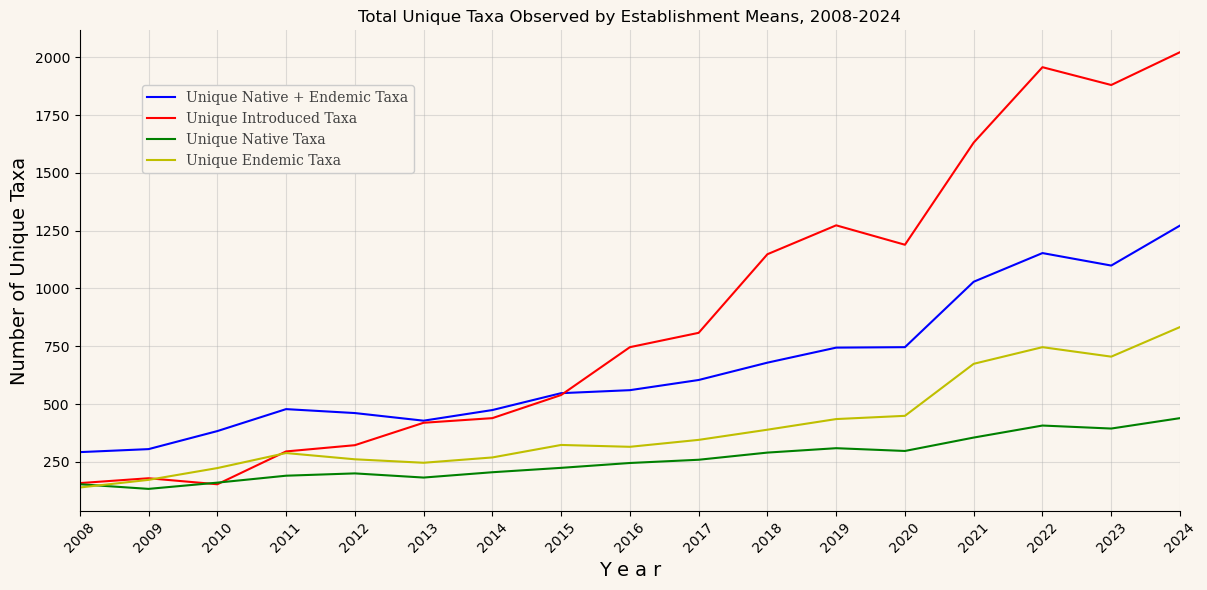

In [ ]:
plot_establishment_trends(totals)

<h4>Plotting Annual Relative Composition by Establishment Means</h4>

In [183]:
def plot_relative_change(totals):
    native_sums = []
    introduced_sums = []
    endemic_sums = []
    years = list(range(2008, 2025))
    for i in years:
        native_sums.append(len(totals.loc[(totals["establishment_means"].str.contains("native"))&(totals[str(i)]>0)][str(i)]))
        introduced_sums.append(len(totals.loc[(totals["establishment_means"].str.contains("introduced"))&(totals[str(i)]>0)][str(i)]))
        endemic_sums.append(len(totals.loc[(totals["establishment_means"].str.contains("endemic"))&(totals[str(i)]>0)][str(i)]))
    N_E_sums = [sum(x) for x in zip(native_sums,endemic_sums)]

    alltotals = []
    for i in range(len(native_sums)):
        alltotals.append(N_E_sums[i]+introduced_sums[i])
 
    native_sums = [(x/y)*100 for x,y in zip(native_sums,alltotals)]
    N_E_sums = [(x/y)*100 for x,y in zip(N_E_sums,alltotals)]
    introduced_sums = [(x/y)*100 for x,y in zip(introduced_sums,alltotals)]
    endemic_sums = [(x/y)*100 for x,y in zip(endemic_sums,alltotals)]


    fig, ax = plt.subplots(figsize = (12,6))
    ax.set_title("Percentage of Total Observations by Establishment Means, 2008-2024")
    ax.set_xticks(years)  
    ax.set_xlabel("Y e a r", fontsize = 14)
    ax.set_ylabel("Percentage of Total Observations", fontsize = 14)
    ax.grid(True, alpha = 0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")
    plt.rcParams['axes.labelcolor'] = '#414141' 
    plt.rcParams['xtick.color'] = '#414141'       
    plt.rcParams['ytick.color'] = '#414141'       
    plt.rcParams['axes.edgecolor'] = '#414141'    
    plt.rcParams['axes.titlecolor'] = '#414141'  
    plt.rcParams['text.color'] = '#414141'      
    plt.rcParams['grid.color'] = '#414141' 
    plt.rcParams['font.family']='serif' 
    plt.xticks(rotation=45) 
    x1 = plt.plot(years,N_E_sums,"b", label ="Unique Native + Endemic Taxa")
    x2 = plt.plot(years, introduced_sums,"r", label = "Unique Introduced Taxa")
    x3 = plt.plot(years, native_sums,"g", label = "Unique Native Taxa")
    x2 = plt.plot(years, endemic_sums,"y", label = "Unique Endemic Taxa")

    ax.legend(loc='center right', bbox_to_anchor=(0.5, 0.4, 0.5, 0.5),facecolor="#FAF5EE", framealpha = 1)
    plt.tight_layout()
    ax.set_xlim(years[0], years[-1])
   # plt.savefig("Relative_Unique_Taxa.png")
    plt.show()

Unfortunately, not every specimen is included in this graph due to missing establishment means data. While I did my best to fill in missing data with reliable data, many (especialy marine) species' ranges are still not officially mapped out. That being said, this graph should cover most terrestrial fauna and flora, and many well-documented marine species as well. 

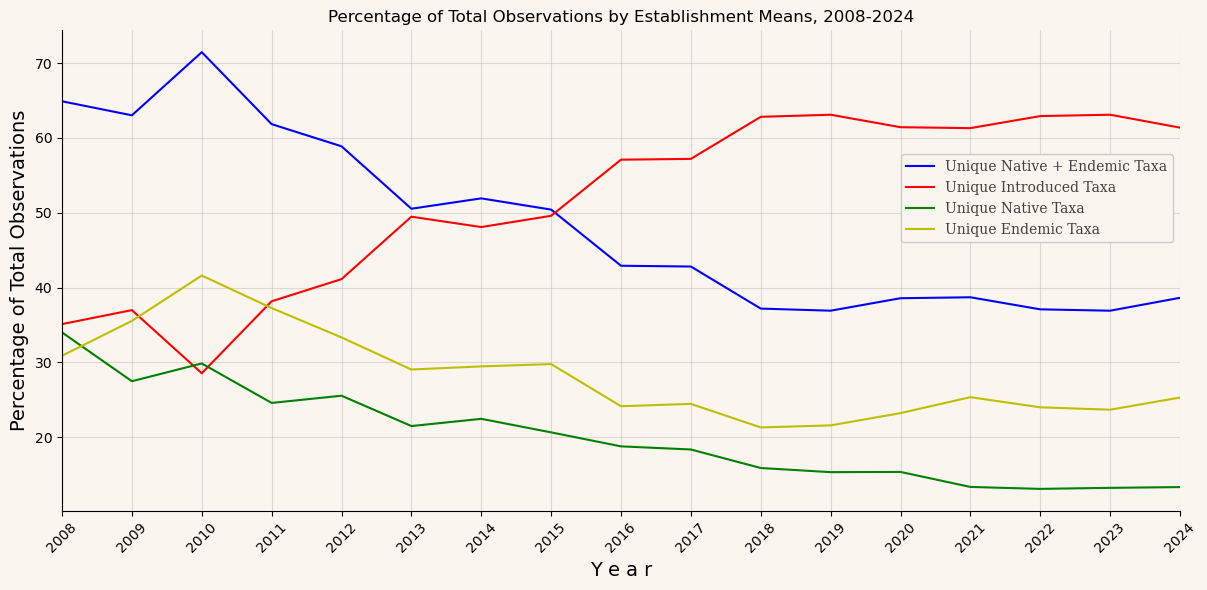

In [164]:
plot_relative_change(totals)

<h2>Are Introduced Species rising, or native species falling? Which species are to blame?</h2>
graph 20 invasive and 20 native species with the greatest change in relative occurances, both increasing and decreasing<br>
or find the most responsible species for the graph changes


<h2>How representative is the INaturalist observation dataset of actual biodiversity?</h2>

<h4>Plotting the Shannon Diversity Index, year over year:</h4>

$$p = \text{proportion of individuals found in the } i\text{th species} $$
$$H = \text{Shannon Diversity Index}$$
$$n = \text{total number of species}$$


$$H=-\Big[\sum_{i=0}^n p\cdot\ln{p}\Big]$$

In [ ]:
def plot_annual_biodiversity(totals):
    indices = []
    years = list(range(2008, 2025))
    indices_one=[]
    indices_two = []
    for i in years:#all taxa
        if str(i) in totals and totals[str(i)].sum() > 0:
            p = totals[str(i)] / totals[str(i)].sum()
            p = p[p > 0]  # Remove zeros to avoid log(0)
            indices.append(-np.sum(p * np.log(p)))  # Shannon Index
        else:
            indices.append(np.nan)  # Keep missing years visible in plot

    for i in years:# change to intriduced only
        total = totals.loc[(totals["establishment_means"]=="native")|(totals["establishment_means"]=="endemic")]
        if str(i) in total and total[str(i)].sum() > 0:
            p = total[str(i)] / total[str(i)].sum()
            p = p[p > 0]  # Remove zeros to avoid log(0)
            indices_one.append(-np.sum(p * np.log(p)))  # Shannon Index
        else:
            indices_one.append(np.nan)  # Keep missing years visible in plot

    for i in years:#change to native only
        total = totals.loc[totals["establishment_means"]=="introduced"]
        if str(i) in total and total[str(i)].sum() > 0:
            p = total[str(i)] / total[str(i)].sum()
            p = p[p > 0]  # Remove zeros to avoid log(0)
            indices_two.append(-np.sum(p * np.log(p)))  # Shannon Index
        else:
            indices_two.append(np.nan)  # Keep missing years visible in plot

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title("Shannon Biodiversity Index, 2008-2024")
    ax.set_xticks(years)  
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Biodiversity Index", fontsize=14)
    ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")

    plt.plot(years, indices, "b", marker="o", label="All Taxa Biodiversity Index")  # Explicit x-values
    plt.plot(years, indices_two, "r", marker="x", label="Introduced Taxa Biodiversity Index")  # Explicit x-values
    plt.plot(years, indices_one, "g", marker="d", label="Native & Endemic Taxa Biodiversity Index")  # Explicit x-values
    
    ax.legend(loc='center right', bbox_to_anchor=(0.0, 0.6, 0.35, 0.5), facecolor="#FAF5EE", framealpha=1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("Annual_Biodiversity.png")
    plt.show()

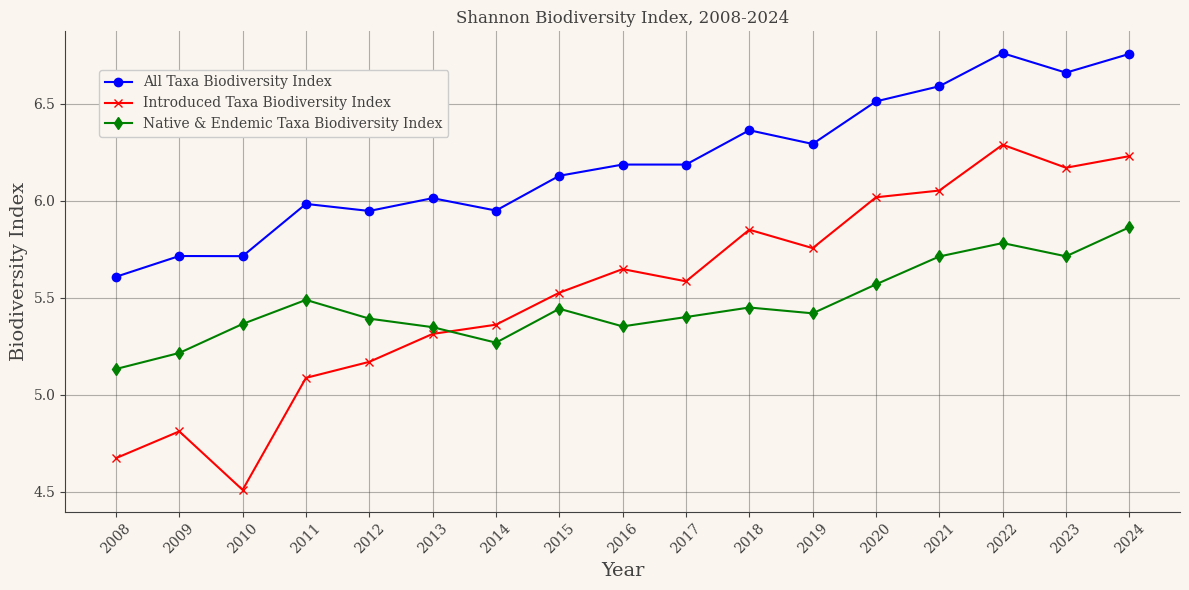

In [ ]:
plot_annual_biodiversity(totals)

In [ ]:
def plot_cumulative_biodiversity(totals):
    indices = []
    years = list(range(2008, 2025))
    indices_one=[]
    indices_two = []
    for i in years:#all taxa
        asum = 0
        for j in range(i,2007,-1):
            asum += totals[str(j)]
        if str(i) in totals and totals[str(i)].sum() > 0:
            p = asum / asum.sum()
            p = p[p > 0]  # Remove zeros to avoid log(0)
            indices.append(-np.sum(p * np.log(p)))  # Shannon Index
        else:
            indices.append(np.nan)  # Keep missing years visible in plot


    total = totals.loc[(totals["establishment_means"]=="native")|(totals["establishment_means"]=="endemic")]
    for i in years:# change to intriduced only
        asum = 0
        for j in range(i,2007,-1):
            asum += total[str(j)]
        if str(i) in total and total[str(i)].sum() > 0:
            p = asum / asum.sum()
            p = p[p > 0]  # Remove zeros to avoid log(0)
            indices_one.append(-np.sum(p * np.log(p)))  # Shannon Index
        else:
            indices_one.append(np.nan)  # Keep missing years visible in plot


    total = totals.loc[totals["establishment_means"]=="introduced"]
    for i in years:#change to native only
        asum = 0
        for j in range(i,2007,-1):
            asum += total[str(j)]
        if str(i) in total and total[str(i)].sum() > 0:
            p = asum / asum.sum()
            p = p[p > 0]  # Remove zeros to avoid log(0)
            indices_two.append(-np.sum(p * np.log(p)))  # Shannon Index
        else:
            indices_two.append(np.nan)  # Keep missing years visible in plot

    print(len(indices_one),len(indices_two))
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title("Shannon Biodiversity Index, 2008-2024")
    ax.set_xticks(years)  
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Biodiversity Index", fontsize=14)
    ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")

    plt.plot(years, indices, "b", marker="o", label="All Taxa Biodiversity Index")  # Explicit x-values
    plt.plot(years, indices_two, "r", marker="x", label="Introduced Taxa Biodiversity Index")  # Explicit x-values
    plt.plot(years, indices_one, "g", marker="d", label="Native & Endemic Taxa Biodiversity Index")  # Explicit x-values
    
    ax.legend(loc='center right', bbox_to_anchor=(0.0, 0.6, 0.35, 0.5), facecolor="#FAF5EE", framealpha=1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("Cumulative_Biodiversity.png")
    plt.show()

17 17


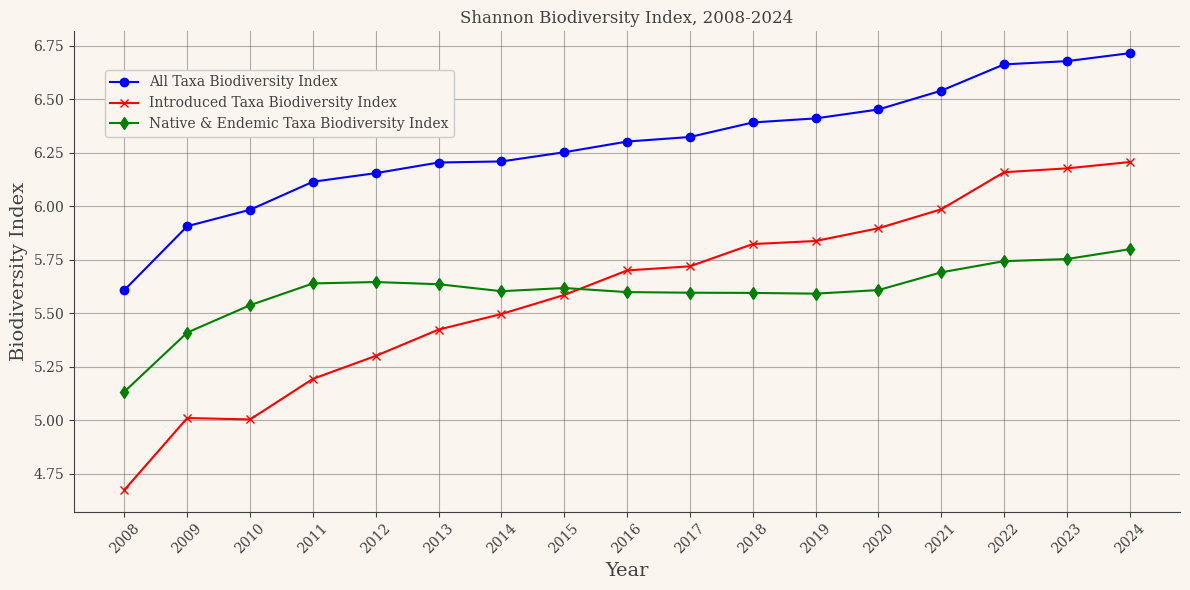

In [ ]:
plot_cumulative_biodiversity(totals)

The results would seem to show that biodiversity is <i>increasing</i>. However, we know that that cannot happen in real life, so this must be an artifact of biased observation sampling. To overcome this, we must use the Chao1 diversity index.


<h4>Chao1 Alpha Diversity index</h4>
Estimates the true number of species in an ecosystem, accounting for rare species and sampling bias. 

$$S_{chao1} = S_{obs} + \frac{n_{1}\cdot{(n_{1}-1)}}{2\cdot{(n_{2}+1)}}$$
$$\text{ }$$
$$S_{chao1} = \text{estimated species richness}$$
$$S_{obs} = \text{observed number of species}$$
$$n_{1} = \text{number of OTU's (taxa) with only one observation}$$
$$n_{2} = \text{number of OTU's (taxa) with only two observations}$$


In [403]:
def plot_annual_richness(total_taxa):
    indices = []
    years = list(range(2008, 2025))
    indices_one=[]
    indices_two = []
    for i in years:#all taxa
        n1 = total_taxa[str(i)].value_counts()[1]
        n2 = total_taxa[str(i)].value_counts()[2]
        s = len(total_taxa.loc[total_taxa[str(i)]>0])
        indices.append(s+((n1*(n1-1))/(2*(n2+1))))


    try:
        for i in years:# change to intriduced only
            total = total_taxa.loc[(total_taxa["establishment_means"]=="native")|(total_taxa["establishment_means"]=="endemic")]
            n1 = total[str(i)].value_counts()[1]
            n2 = total[str(i)].value_counts()[2]
            s = len(total.loc[total_taxa[str(i)]>0])
            indices_one.append(s+((n1*(n1-1))/(2*(n2+1))))

        for i in years:# change to intriduced only
            total = total_taxa.loc[(total_taxa["establishment_means"]=="introduced")]
            n1 = total[str(i)].value_counts()[1]
            n2 = total[str(i)].value_counts()[2]
            s = len(total.loc[total_taxa[str(i)]>0])
            indices_two.append(s+((n1*(n1-1))/(2*(n2+1))))
    except BaseException:
        pass
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title("Chao1 Diversity Index, 2008-2024")
    ax.set_xticks(years)  
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Estimated Number of Species", fontsize=14)
    ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")

    plt.plot(years, indices, "b", marker="o", label="All Taxa")  # Explicit x-values
    try:
        plt.plot(years, indices_two, "r", marker="x", label="Introduced Taxa")  # Explicit x-values
        plt.plot(years, indices_one, "g", marker="d", label="Native & Endemic Taxa")  # Explicit x-values
    except BaseException:
        pass
    ax.legend(loc='center right', bbox_to_anchor=(0.0, 0.6, 0.25, 0.5), facecolor="#FAF5EE", framealpha=1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("Annual_Richness.png")
    plt.show()

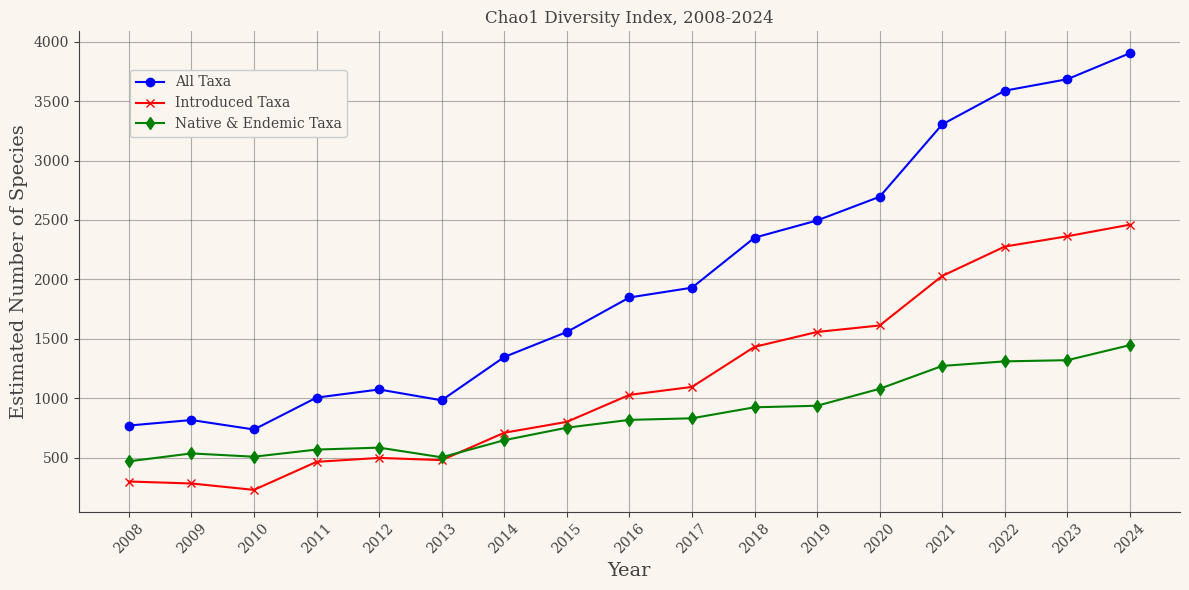

In [404]:
plot_annual_richness(totals)

I am incrementing through years of a dataframe, which contains unique species names, along with their annual totals. my df has years 2008 through 2024 as column names. For each increment of the for loop i in range(i,2007,-1) where i is a given year in the column names (from a previous for loop) I want to get the total amount of unique species in the range 2008 to i that have observations 

In [414]:
def plot_cumulative_richness(total_taxa): #THIS IS WRONG AND UNNECESSARY. IT ADDS N1 and N2 EACH ITERATION, HOWEVER, I NEED TO SUM EACH CUMULATION BEFORE FINDING N1 AND N2
    indices = []
    years = list(range(2008, 2025))
    indices_one=[]
    indices_two = []
    for i in years:#all taxa
        n1=0
        n2=0
        for j in range(i, 2007, -1):
            n1 += total_taxa[str(j)]
            n2 += total_taxa[str(j)]
            #all rows whose columns between 2008 and str(i) contain atleast one nonzero value
        n1=n1.value_counts()[1]
        n2=n2.value_counts()[2]
        s = len(total_taxa.loc[(total_taxa.loc[:,total_taxa.columns[total_taxa.columns.get_loc(str(i)):total_taxa.columns.get_loc("2007")]]!=0).any(axis=1)])
        indices.append(s+((n1*(n1-1))/(2*(n2+1))))


    try:
        for i in years:#Native or endemic
            total = total_taxa.loc[(total_taxa["establishment_means"]=="native")|(total_taxa["establishment_means"]=="endemic")]
            n1=0
            n2=0
            for j in range(i, 2007, -1):
                n1 += total[str(j)]
                n2 += total[str(j)]
                #all rows whose columns between 2008 and str(i) contain atleast one nonzero value
            n1=n1.value_counts()[1]
            n2=n2.value_counts()[2]
            s = len(total.loc[(total.loc[:,total.columns[total.columns.get_loc(str(i)):total.columns.get_loc("2007")]]!=0).any(axis=1)])
            indices_one.append(s+((n1*(n1-1))/(2*(n2+1))))
    except BaseException:
        pass

    try:
        for i in years:#Introduced
            total = total_taxa.loc[(total_taxa["establishment_means"]=="introduced")]
            n1=0
            n2=0
            for j in range(i, 2007, -1):
                n1 += total[str(j)]
                n2 += total[str(j)]
                #all rows whose columns between 2008 and str(i) contain atleast one nonzero value
            n1=n1.value_counts()[1]
            n2=n2.value_counts()[2]
            s = len(total.loc[(total.loc[:,total.columns[total.columns.get_loc(str(i)):total.columns.get_loc("2007")]]!=0).any(axis=1)])
            indices_two.append(s+((n1*(n1-1))/(2*(n2+1))))
    except BaseException:
        pass
    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title("Chao1 Diversity Index, 2008-2024")
    ax.set_xticks(years)  
    ax.set_xlabel("Year", fontsize=14)
    ax.set_ylabel("Estimated Number of Species", fontsize=14)
    ax.grid(True, alpha=0.4)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")

    plt.plot(years, indices, "b", marker="o", label="All Taxa")  # Explicit x-values
    try:
        plt.plot(years, indices_one, "g", marker="x", label="Native & Endemic Taxa")  # Explicit x-values
        plt.plot(years, indices_two, "r", marker="d", label="Introduced Taxa")  # Explicit x-values
    except BaseException as e:
        pass
    ax.legend(loc='center right', bbox_to_anchor=(0.0, 0.6, 0.25, 0.5), facecolor="#FAF5EE", framealpha=1)
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("Cumulative_Richness_All_Obs.png")
    plt.show()
    print(indices)

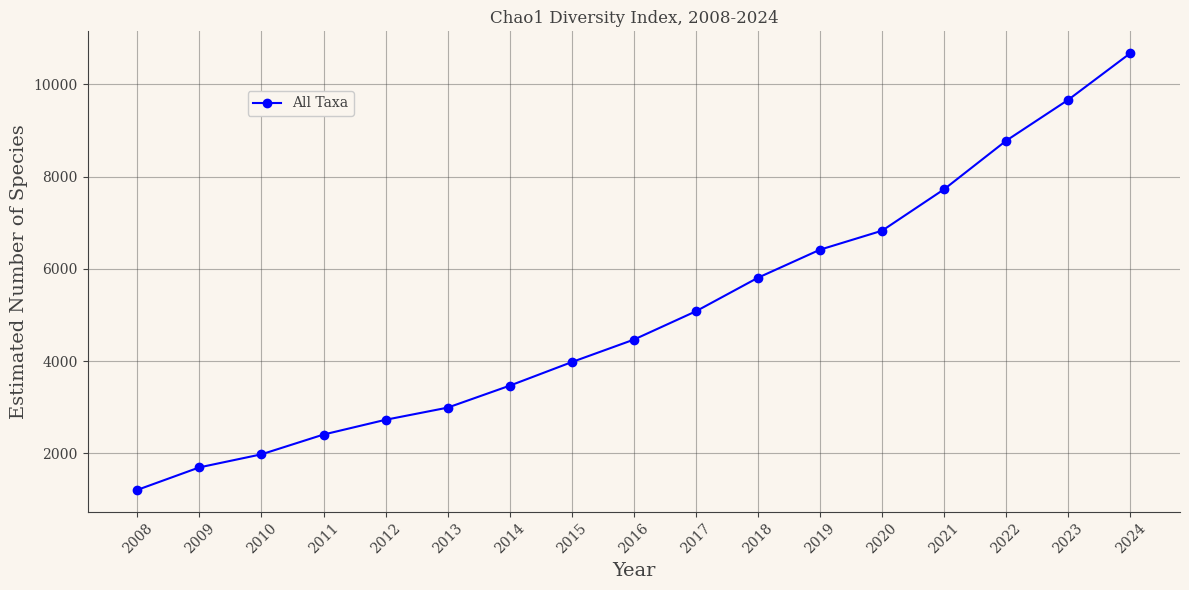

[1210.525, 1698.2227722772277, 1980.9857142857143, 2409.4197860962568, 2729.5226666666667, 2992.485294117647, 3468.3108808290153, 3979.2317380352642, 4466.03595505618, 5080.135922330097, 5807.183177570094, 6415.126475548061, 6826.567233384853, 7724.896408839779, 8776.917001338688, 9663.333333333334, 10672.869147659063]


In [415]:
plot_cumulative_richness(totals2)

In [420]:
print(len(graph2["taxon_name"].value_counts()))

8657


The highest Chao1 Diversity index shows that it predicts that there is 10,673 species in hawaii. This is substantially lower than the Bishop Museum's estimate of 21300, suggesting that INaturalist's data has only captured about half of the archipelago's biodiversity since its inception.
Likely underrepresents:
Microscopic organisms
Cryptic species (those difficult to identify from photos)
Nocturnal species
Deep marine species
Many invertebrate groups

Demonstrates the limitations of citizen science platoforms for comprehensive biodiversity assessment especially in places with high taxonomic complexity and endemism.

Indeed, print(len(graph2["taxon_name"].value_counts())) returns only 8657 unique species observed. That is less than half the total. 

<h3>Establishing a new DataFrame that includes every observation regardless of establishment means</h3>
This should grant a higher diversity index accuracy

In [ ]:
#Get Unique Years across all observations in descending order
years = data.loc[data["observed_on"].notna(),"observed_on"]
years = years.str[0:4].astype(int)
years = np.sort(years.unique())[::-1]

#Filter out the speciments with valid important data points. Includes invalid establishment means
graph2 = data.loc[(data["taxon_name"].str.contains(' '))&(data["observed_on"].notna())] 
#dataframe with selected information from the cleaned dataset
cols2 = ["total_observations_08-24"]
for i in years:
    cols2.append(str(i))
totals2 = pd.DataFrame(columns=cols2)
keywords = []
for i in range(2008,2025):
    keywords.append(str(i))
    keyword = '|'.join(keywords)
totals2["total_observations_08-24"] = graph2.loc[graph2["observed_on"].str[0:4].str.contains(keyword)]["taxon_name"].value_counts()
taxon_list = totals2.index
for i in (years):
    totals2[str(i)] = get_yearly_totals(graph2, i, taxon_list)
combine_subspecies(totals2)
#Subspecies data is retained, however species level data now reflects the sum of its subspecies


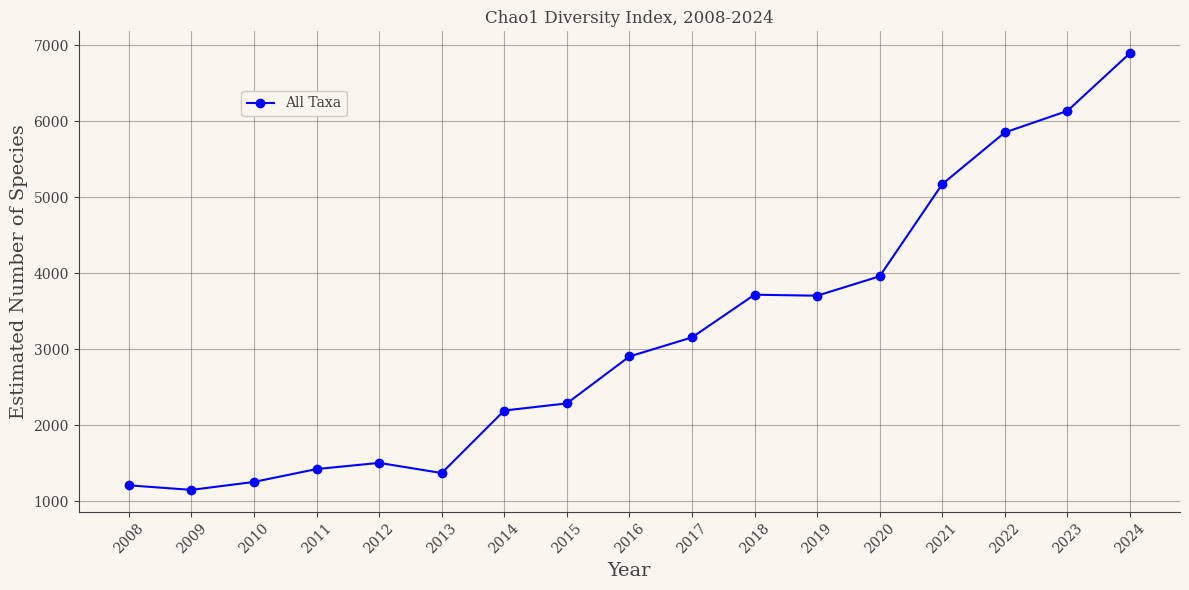

In [116]:
plot_richness(totals2)

Unfortuntely, given that the estimiated species richness graph has not plateaued yet and the measured species richness shows linear growth, it is safe to say that INaturalist's observations do not accurately represent the ecological makeup of the Hawaiian Archipelago. According to the Bishop Museum, we should expect to see approximately 21,383 species, 8759 of which are endemic and 4532 are introduced, if INaturalist users were able to document every one. Even still, estimated richness of 7,000 species as of 2024 is only a third of the total. Need to calculate the total Chao1 index.

,total_observations,2025,2024,2023,2022,2021,2020,2019,2018,2017,...,1969,1967,1961,1947,1946,1945,1944,1943,1933,1893
taxon_name,,,,,,,,,,,,,,,,,,,,,
Chelonia mydas,8165,115,1212,1000,1321,877,314,641,498,320,...,1,0,0,0,0,0,0,0,0,0
Paroaria coronata,6653,128,1322,970,1226,906,268,716,341,204,...,0,0,0,0,0,0,0,0,0,0
Geopelia striata,6215,171,1324,951,1065,732,193,684,377,190,...,0,0,0,0,0,0,0,0,0,0
Phelsuma laticauda,7400,130,1538,1199,1338,975,362,697,419,243,...,1,0,0,0,0,0,0,0,0,0
Metrosideros polymorpha,5925,173,1252,823,1194,763,197,420,249,143,...,0,0,0,0,0,0,0,0,0,0


In [ ]:
n1 = totals2["total_observations_08-24"].value_counts()[1]
n2 = totals2["total_observations_08-24"].value_counts()[2]
s = len(totals2.loc[totals2["total_observations_08-24"]>0])
print(s+((n1*(n1-1))/(2*(n2+1))))

10688.156698564593


The Total chao1 Index is a little over half of how many species we should expect if INaturalist were decently varied in its observations. This means that their data is missing a lot of species. Rarefaction would be required to et a better sense of biodiversity, however, given the rarity of so many species, the results would be greatly skewed (via wikipedia)<br><br>
Reasons:<br>
Some regions may be more oversampled than others (particularly urban environments vs marine environments or reserves) <br>
Some regions, such as those with the highest biodiversity in reserves or restricted areas, have no sampling at all<br>


Flow:
Chart basic metrics
chart diversity
why is diversity not represented with inaturalist?
Quantifying how bad it is
Can we visualize why geospatially?
If the data isnt great for biodiversity, are there specific things we can use it for, such as invasive species  reporting and mapping or migration patterns? Range shifts? Public Engagement? Highlight how invasive species are more commonly observed than native ones, highlight why more public knowledge needs to be had.

Formal surveys probably arent as good for migratory birds.



<h3>Seasonality bias in observations</h3>

In [ ]:
def plot_seasonality_bias(input_data):
    months=["January","February","March","April","May","June","July","August","September","October","November","December"]
    months_values=[]

    fig, ax = plt.subplots(figsize=(12, 6))
    ax.set_title("Total Observations by Month, All Time", fontsize = 16)
    ax.set_xlabel("Year", fontsize=17)
    ax.set_ylabel("Number of Observations", fontsize=16)
    ax.set_xmargin(0.01)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")
    ax.tick_params(axis='x', labelsize=12)

    for i in range(1,13):
        months_values.append(len(data.loc[data["observed_on"].str[5:7].str.lstrip('0')==str(i)]))
        plt.text(i-1.25,months_values[i-1]+200,months_values[i-1], weight="bold")

    plt.bar(months, months_values, color='#f78243')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.savefig("Seasonality_Bias.png")
    plt.show()

https://roadgenius.com/wp-content/uploads/2024/08/us-hawaii-monthly-tourism-trend-best-time-to-visit-1024x559.jpg

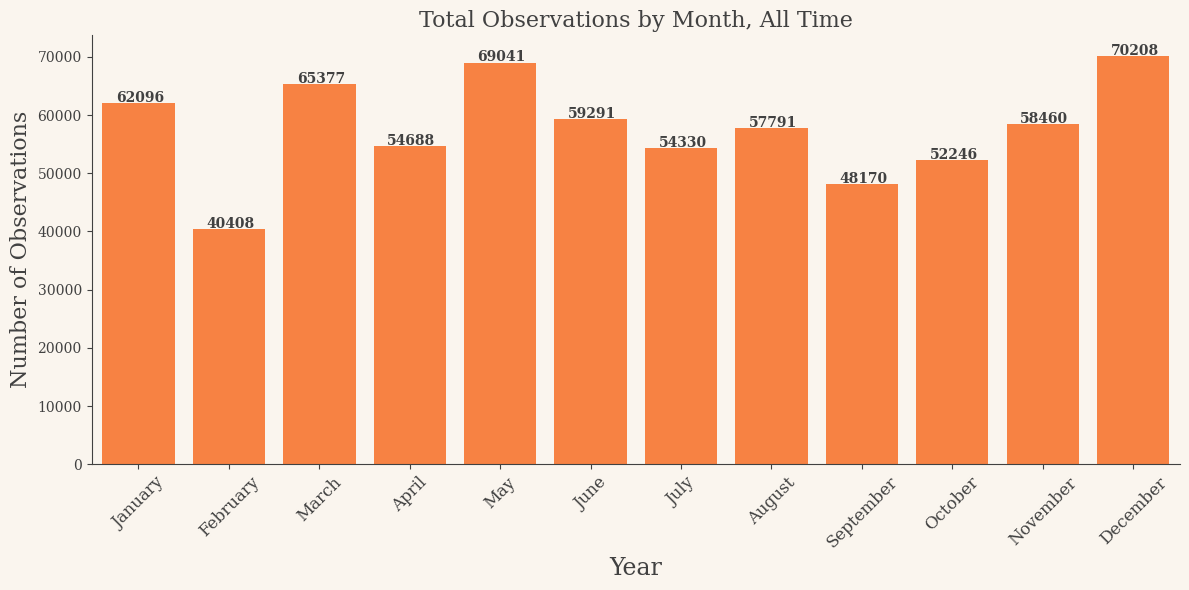

In [227]:
plot_seasonality_bias(data)

<h3>Identifying the most observed taxa</h3>

There are 3814 Magnoliopsida specimens, a family which comprises about half of all flowering plants. These observations are identified to family, but an exact species ID is needed. Many of these are probably native or endemic species, though they cannot be verified. 

In [7]:

def Plot_Top_Taxa():
    #establish a df of the top species by count and a random picture of one of them. 
    #Each bar has a picture above it, click to enlarge, hover for copyrights
    b=[]
    c=[]
    d=[]
    e=[]
    a = data.loc[data["taxon_rank"]=="species","taxon_name"].value_counts()[0:10]
    for i in range(0,10):
        b.append(data.loc[(data["taxon_name"]==a.index[i])&(data["taxon_rank"]=="species"),"establishment_means"].iloc[0])
        c.append(data.loc[(data["taxon_name"]==a.index[i])&(data["taxon_rank"]=="species"),"photo_url"].iloc[0])
        d.append(data.loc[(data["taxon_name"]==a.index[i])&(data["taxon_rank"]=="species"),"copyright"].iloc[0])
        e.append(data.loc[(data["taxon_name"]==a.index[i])&(data["taxon_rank"]=="species"),"preferred_common_name"].iloc[0])

    taxa = pd.DataFrame()
    taxa["counts"]=a
    taxa["establishment_means"]=b
    taxa["photo_url"]=c
    taxa["copyright"]=d
    taxa["pcn"] = e
    taxa["pcn"] = taxa["pcn"].str.cat(taxa.index, sep = " (")+")"

    fig, ax = plt.subplots(figsize =(12,5))
    ax.barh(taxa["pcn"], taxa["counts"], color="orange")
    ax.set_title("Species with the Most Observations", fontsize = 16)
    ax.title.set_position([0.25,10])
    ax.invert_yaxis()
    y_pos = np.arange(len(a.index))
    ax.set_yticks(taxa["pcn"])
    ax.set_xbound(3000,9000)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_facecolor("#FAF5EE")
    fig.set_facecolor("#FAF5EE")
    ax.tick_params(axis='x', )
    ax.set_xticks([])  # Removes the x-tick marks
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    ax.yaxis.set_tick_params(color="#FAF5EE")
    ax.tick_params(axis='y', labelcolor='black')  # Set y-tick labels to black

    for i in range(11,1,-1):
        plt.text(taxa["counts"].iloc[i-2]+70,(i-1.85),taxa["counts"].iloc[i-2], weight="bold")


    plt.tight_layout()
    plt.show()
    

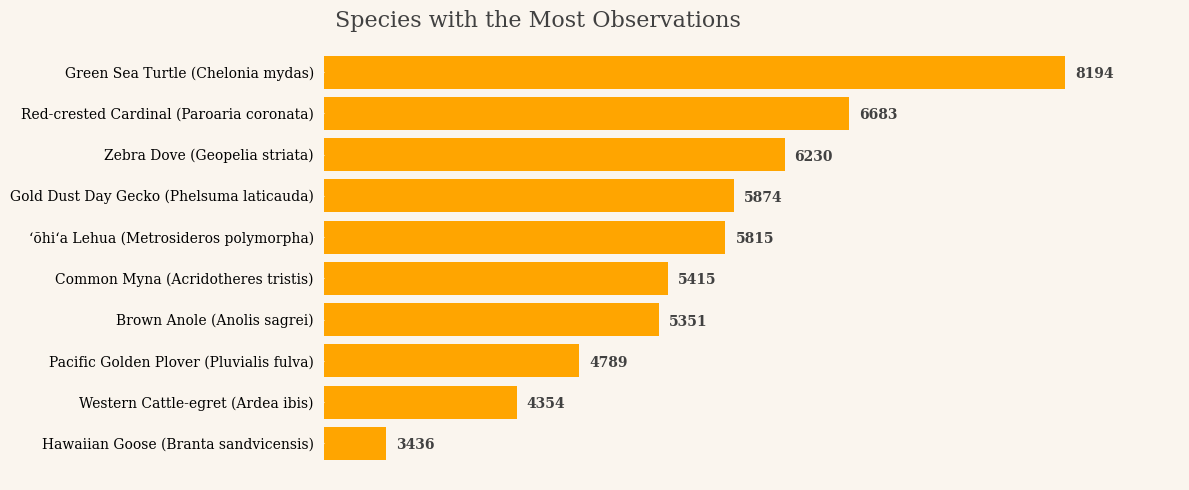

In [240]:
Plot_Top_Taxa()

<h2>With Plotly</h2>

In [17]:
def Plot_Top_Taxa_2():
    b = []
    c = []
    d = []
    e = []
    a = data.loc[data["taxon_rank"] == "species", "taxon_name"].value_counts()[0:10]
    
    for i in range(0, 10):
        b.append(data.loc[(data["taxon_name"] == a.index[i]) & (data["taxon_rank"] == "species"), "establishment_means"].iloc[0])
        c.append(data.loc[(data["taxon_name"] == a.index[i]) & (data["taxon_rank"] == "species"), "photo_url"].iloc[0])
        d.append(data.loc[(data["taxon_name"] == a.index[i]) & (data["taxon_rank"] == "species"), "copyright"].iloc[0])
        e.append(data.loc[(data["taxon_name"] == a.index[i]) & (data["taxon_rank"] == "species"), "preferred_common_name"].iloc[0])
    
    # Create a DataFrame
    print(c)
    taxa = pd.DataFrame()
    taxa["counts"] = a
    taxa["establishment_means"] = b
    taxa["photo_url"] = c
    taxa["copyright"] = d
    taxa["pcn"] = e
    taxa["pcn"] = taxa["pcn"].str.cat(taxa.index, sep=" (") + ")"
    
    # Create a color mapping for establishment_means
    color_map = {
        "native": "#4CAF50",      # Green
        "introduced": "#F44336",  # Red
        "endemic": "#2196F3"      # Blue
    }
    
    # Map colors based on establishment_means
    colors = [color_map.get(status, "#9E9E9E") for status in taxa["establishment_means"]]
    
    # Prepare hover texts with HTML images
    hover_texts = []
 
    img_html = [f'<img src="{url}" width="150">' for url in c]

    # Create a Plotly bar chart
    fig = go.Figure()
    fig.add_trace(go.Bar(
        x=taxa["counts"],
        y=taxa["pcn"],
        orientation='h',
        marker=dict(
            color=colors
        ),
        hoverinfo="text",
        hovertemplate = "%{img_html}<extra></extra>",
        text=taxa["establishment_means"],
        textposition="inside",
        insidetextanchor="middle"
    ))
    
    # Add a legend
    for status, color in color_map.items():
        fig.add_trace(go.Scatter(
            x=[None],
            y=[None],
            mode='markers',
            marker=dict(size=10, color=color),
            name=status.capitalize(),
            showlegend=True
        ))
    
    # Customize the layout
    fig.update_layout(
        title="Species with the Most Observations",
        plot_bgcolor="#FAF5EE",
        paper_bgcolor="#FAF5EE",
        xaxis=dict(showgrid=False, zeroline=False),
        yaxis=dict(showgrid=False),
        margin=dict(l=0, r=0, t=50, b=50),
        legend=dict(
            orientation="h",
            yanchor="bottom",
            y=1.02,
            xanchor="right",
            x=1
        ),
        hoverlabel=dict(
            bgcolor="white",
            font_size=12,
            font_family="Arial"
        )
    )
    
    # Enable HTML in hover labels
    fig.update_layout(hovermode="closest")
    
    fig.write_html("Most_Observed_Species.html")
    # Show the figure
    fig.show()

In [18]:
Plot_Top_Taxa_2()

['https://inaturalist-open-data.s3.amazonaws.com/photos/468300961/original.jpg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468316363/original.jpeg', 'https://static.inaturalist.org/photos/468328132/original.jpg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468291577/original.jpg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468330992/original.jpeg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468330340/original.jpg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468323914/original.jpeg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468316495/original.jpeg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468287163/original.jpg', 'https://inaturalist-open-data.s3.amazonaws.com/photos/468298641/original.jpg']
